In [1]:
# Put the project directory on the path to make sure we can import PyNitride
import sys, os
sys.path.append(os.path.abspath("../"))

In [2]:
#%matplotlib qt
#%matplotlib notebook
%matplotlib inline
from ipywidgets import interact, FloatSlider
import numpy as np
from pynitride import ParamDB
import matplotlib.pyplot as plt
pmdb=ParamDB(units='si')
to_units=pmdb.to_units
from pynitride.compact.models import GaNHEMT_iMVSG, VO2Res, HyperFET, Direction
import warnings
import matplotlib

In [3]:
matplotlib.rcParams.update({'font.size':22})

In [24]:
500/(.5-.25)

2000.0

In [11]:
.1/1.4

0.07142857142857144

In [20]:
.6e-1*50e-9

2.9999999999999996e-09

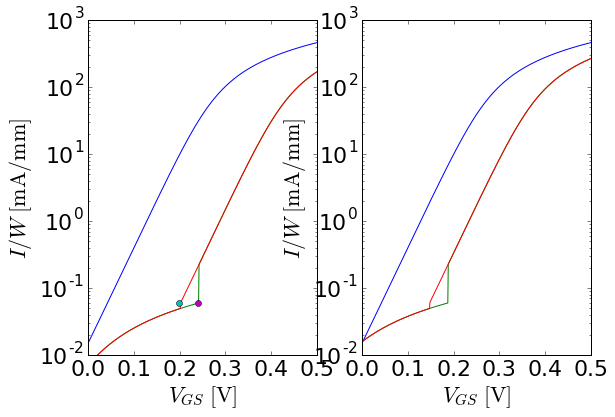

In [31]:
@interact(VT0=FloatSlider(value=.25,min=0,max=1,step=.05,continuous_update=False),
          Cinv_vxo=FloatSlider(value=2000,min=1000,max=5000,step=400,continuous_update=False),
          SS=FloatSlider(value=.070,min=.06,max=.08,step=.02,continuous_update=False),
          alpha=FloatSlider(value=0,min=0,max=5,step=.5,continuous_update=False),
          beta=FloatSlider(value=1.8,min=0,max=4,step=.1,continuous_update=False),
          VDsats=FloatSlider(value=3.5,min=.5,max=10,step=.1,continuous_update=False),
          log10Gleak=FloatSlider(value=-12,min=-14,max=-5,step=1,continuous_update=False),
          #Rs=FloatSlider(value=0,min=0,max=30,step=1,continuous_update=False),
          #Rd=FloatSlider(value=0,min=0,max=30,step=1,continuous_update=False),
          
          I_IMT=FloatSlider(value=3e-9,min=0,max=1e-8,step=.5e-9,continuous_update=False),
          V_IMT=FloatSlider(value=.1,min=0,max=1,step=.02,continuous_update=False),
          I_MIT=FloatSlider(value=3e-9,min=0,max=1e-8,step=.5e-9,continuous_update=False),
          V_MIT=FloatSlider(value=.1,min=0,max=1,step=.02,continuous_update=False),
          R_met=FloatSlider(value=0.005,min=0,max=0.02,step=.001,continuous_update=False)
         )         
def show_HyperFET(VT0,Cinv_vxo,SS,alpha,beta,VDsats,log10Gleak,
                  I_IMT,V_IMT,I_MIT,V_MIT,R_met):
    plt.figure(figsize=(9,6))
    #plt.figure()
    #plt.cla()
    Rs=Rd=0
    W=50e-9
    hemt=GaNHEMT_iMVSG(
        W=W,Cinv_vxo=Cinv_vxo,
        VT0=VT0,alpha=alpha,SS=SS,delta=0,
        VDsats=VDsats,beta=beta,eta=0,Gleak=10**log10Gleak,Rs=Rs,Rd=Rd)
    vo2=VO2Res(I_IMT=I_IMT,V_IMT=V_IMT,I_MIT=I_MIT,V_MIT=V_MIT,R_met=R_met)
    
    hf=HyperFET(hemt,vo2)
    
    VD=np.array(10.0)
    VG=np.linspace(0,.5,500)

    plt.subplot(121)
    I=hemt.ID(VD=VD,VG=VG)
    plt.plot(VG,I/hemt.W)
    
    
    If,Ib=[np.ravel(i) for i in hf.I_double(VD=VD,VG=VG)]
    plt.plot(VG[~np.isnan(If)],If[~np.isnan(If)]/hemt.W)
    plt.plot(VG[~np.isnan(Ib)],Ib[~np.isnan(Ib)]/hemt.W)
    
    plt.plot(hf.approx_hyst("Vleft"),vo2.I_MIT/hemt.W,'o')
    plt.plot(hf.approx_hyst("Vright"),vo2.I_IMT/hemt.W,'o')
    
    
    floor=10**log10Gleak*VD
    
    # Because yscale log complains about NaNs
    with warnings.catch_warnings():
        warnings.filterwarnings('ignore')
        plt.yscale('log')
        plt.ylim(1e-2,1e3)
        plt.xlabel("$V_{GS}\;\mathrm{[V]}$")
        plt.ylabel("$I/W\;\mathrm{[mA/mm]}$")
        
        
    plt.subplot(122)
    
    
    hemtshifted=GaNHEMT_iMVSG(
        W=W,Cinv_vxo=Cinv_vxo,
        VT0=VT0+HyperFET.approx_shift(hemt,vo2),alpha=alpha,SS=SS,delta=0,
        VDsats=VDsats,beta=beta,eta=0,Gleak=10**log10Gleak,Rs=Rs,Rd=Rd)
    hf=HyperFET(hemtshifted,vo2)
    
    plt.plot(VG,I/hemt.W)
    If,Ib=[np.ravel(i) for i in hf.I_double(VD=VD,VG=VG)]
    plt.plot(VG[~np.isnan(If)],If[~np.isnan(If)]/hemt.W)
    plt.plot(VG[~np.isnan(Ib)],Ib[~np.isnan(Ib)]/hemt.W)
    
    with warnings.catch_warnings():
        warnings.filterwarnings('ignore')
        plt.yscale('log')
        plt.ylim(1e-2,1e3)
        plt.xlabel("$V_{GS}\;\mathrm{[V]}$")
        plt.ylabel("$I/W\;\mathrm{[mA/mm]}$")
        
        
    #plt.gcf().canvas.draw()